# (09) iP-VAE: MNIST

project = ```iP-VAE```, host = ```solo```, device = ```cuda:0```

**Motivation**: <br>

Does liear model work on MNIST? Not really.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: solo

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'grad|lin')
cfg_vae['seq_len'] = 8
cfg_vae['n_latents'] = 256

cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 2.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'MNIST', 'n_latents': 256, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.001, 'seq_len': 8, 'track_stats': True}

Trainer:
{'epochs': 400, 'batch_size': 200, 'warm_restart': 1, 'optimizer_kws': {'weight_decay': 0.0003}, 'chkpt_freq': 20, 
'grad_clip': 150, 'kl_beta': 2.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  202.0 K   |
|     ———     |    ———     |
|    layer    |  202.0 K   |
+-------------+------------+

poisson_MNIST_t-8×1_b-1_z-[256]_<grad|lin>
b200-ep400-lr(0.002)_beta(2:0x0.1)_temp(0.05:lin-0.5)_gr(150)_(2025_02_09,19:05)

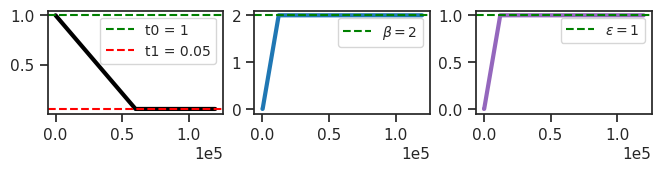

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

PoissonLayer(input_dim=784,latent_dim=256, beta_inner=1, temp=1)

In [6]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 400, avg loss: -1360.988891: 100%|████| 400/400 [49:29<00:00,  7.42s/it]


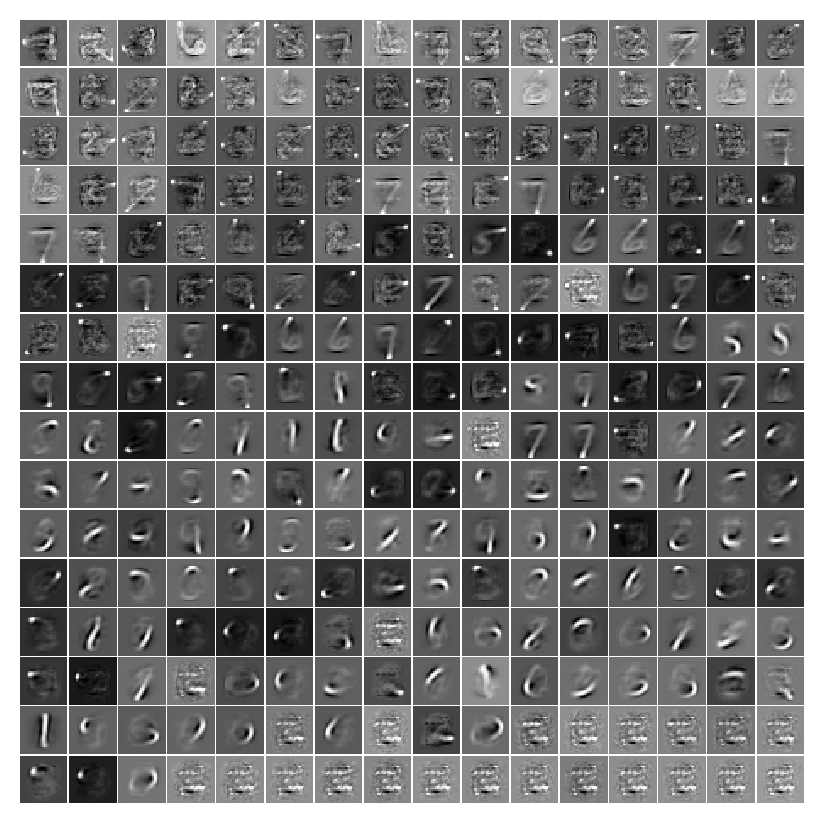

In [7]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

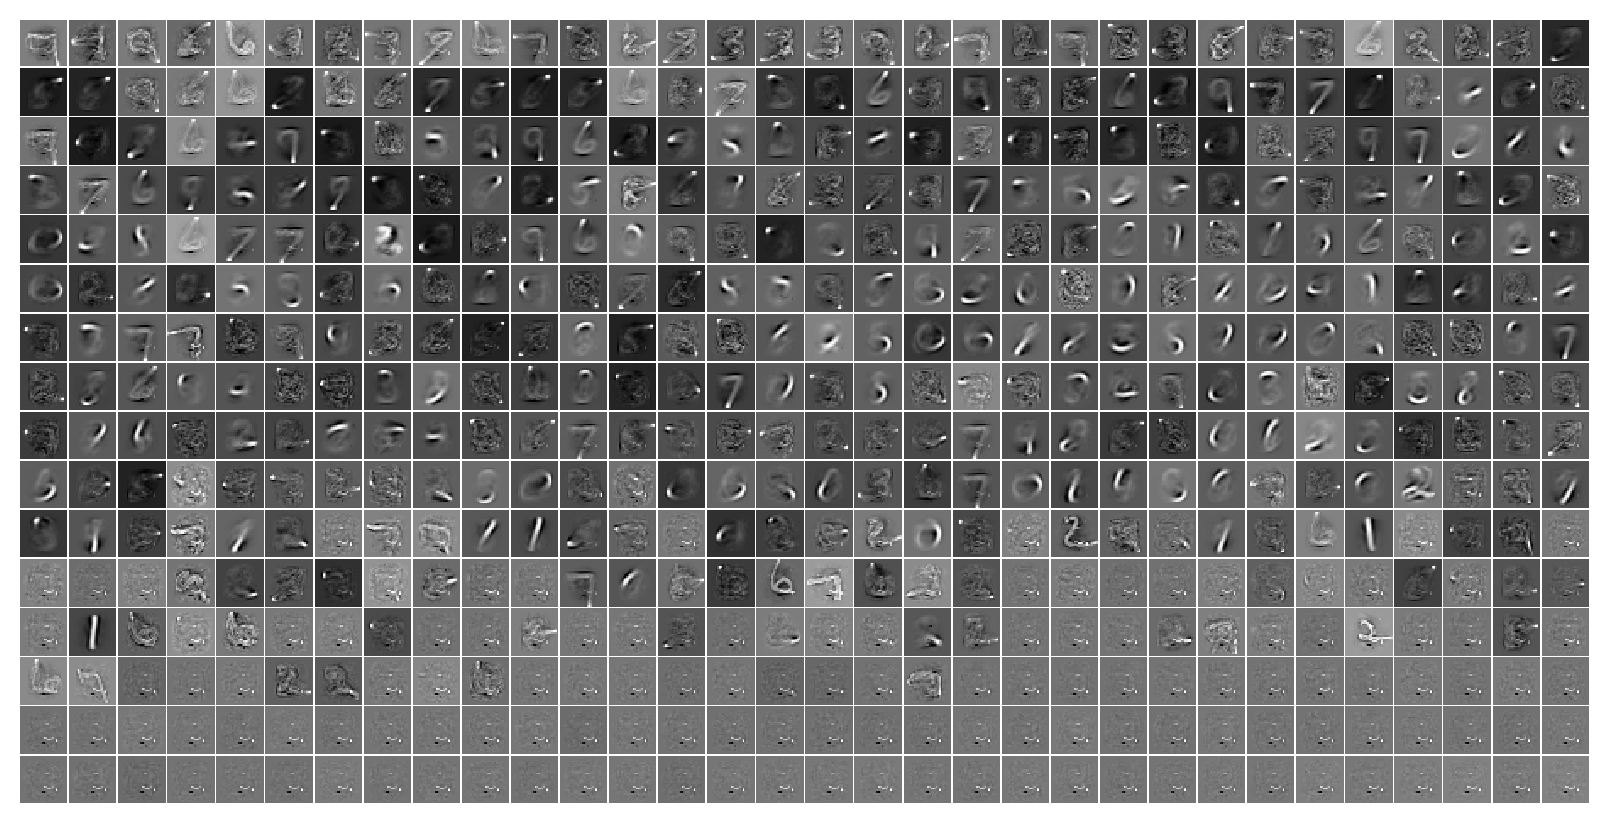

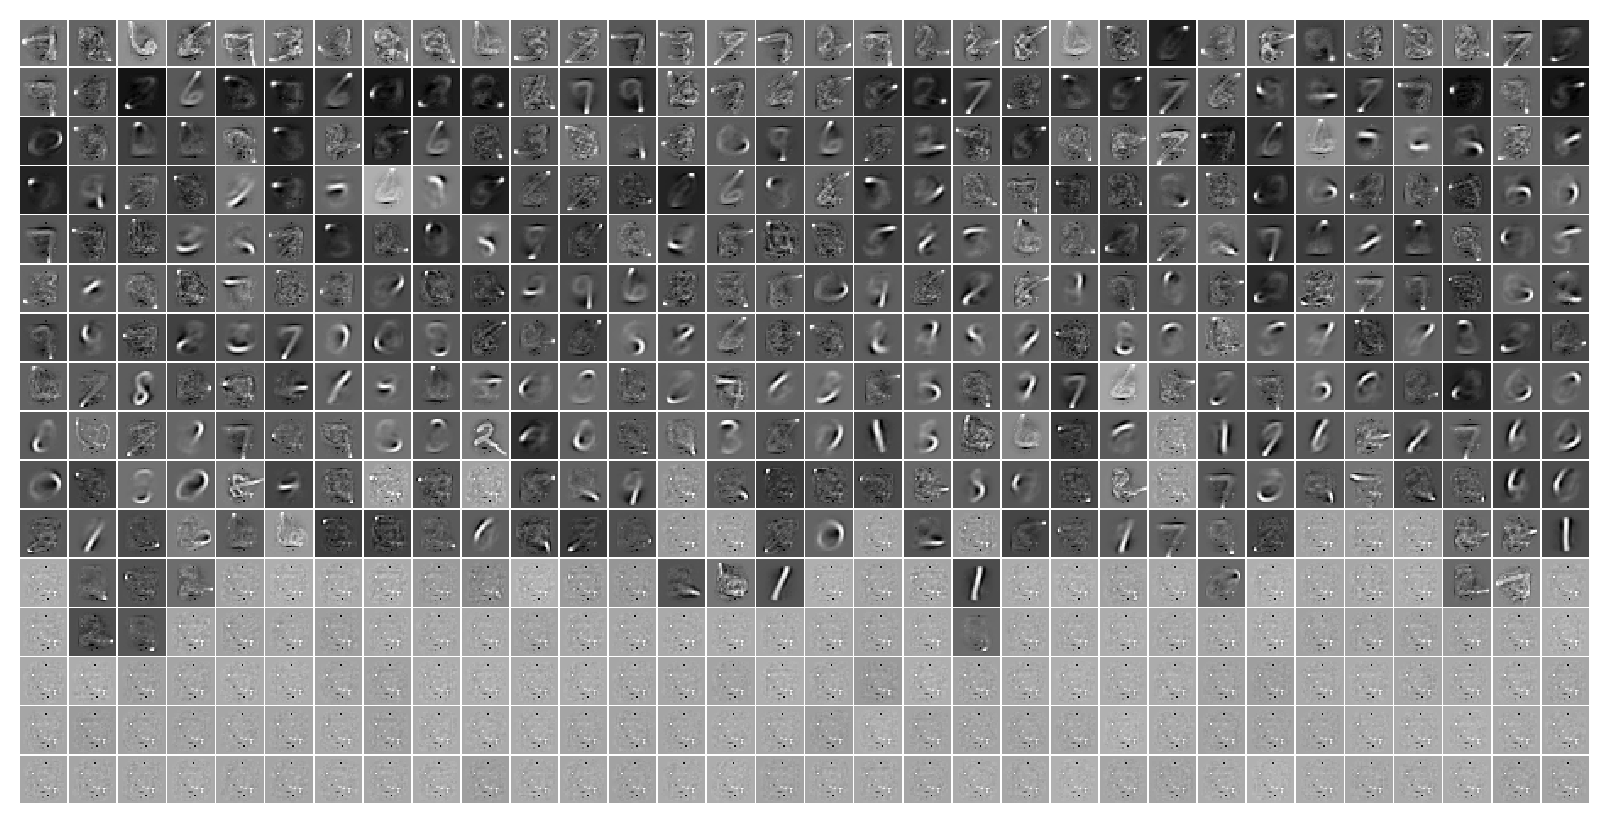

In [9]:
### Was: beta = 16.0

In [10]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

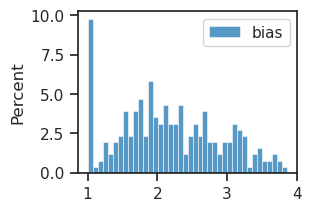

tensor([0.1032], device='cuda:0', grad_fn=<ExpBackward0>)

In [11]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(bias, label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

tr.model.layer.log_lr.exp()

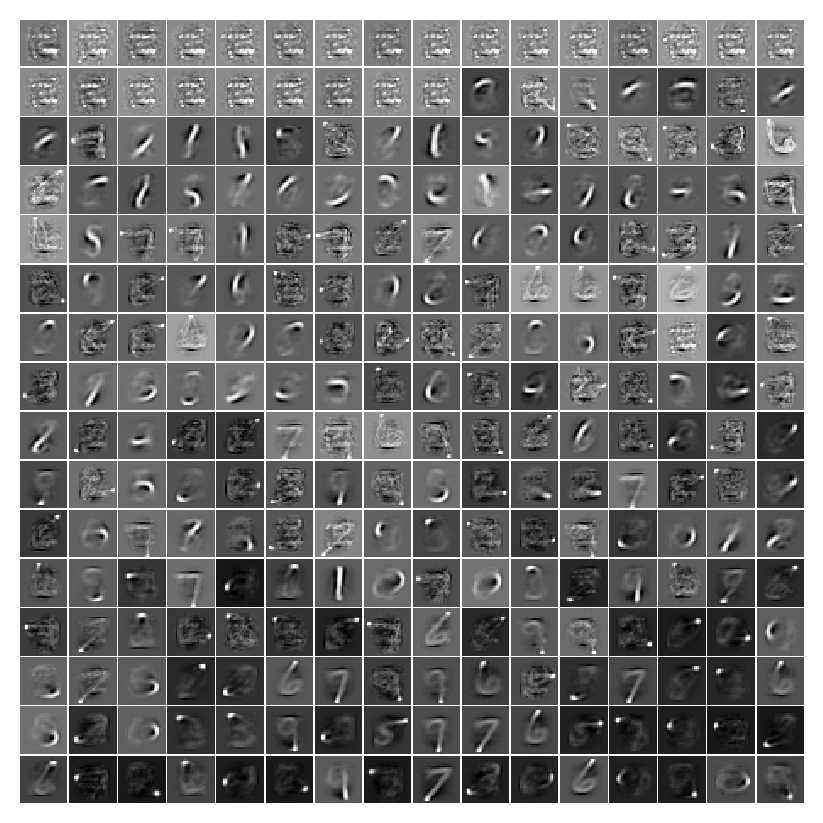

In [12]:
tr.model.show(order=np.argsort(bias));

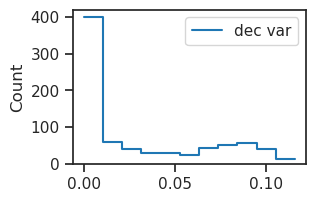

In [13]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()

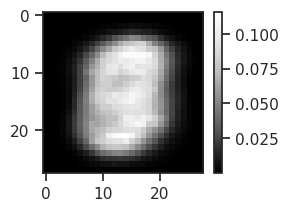

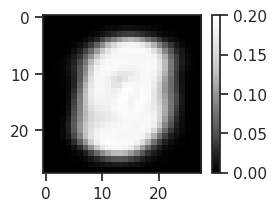

In [14]:
var = np.exp(log_scale) ** 2
var = var.reshape(28, 28)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar();

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar();

In [15]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 2.47 s, sys: 92 ms, total: 2.56 s
Wall time: 2.56 s


[0.9630138874053955,
 0.9623258113861084,
 0.9627314805984497,
 0.9629937410354614,
 0.962984561920166]

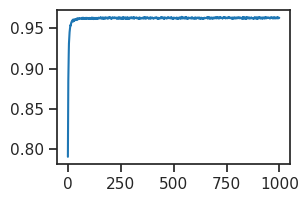

In [16]:
from analysis.sparse import sparse_score

t = 0
lifetime, population = [], []
for t in range(1000):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

In [17]:
output['loss_recon'].mean(0)[-5:]

tensor([-1458.4009, -1449.2240, -1471.3936, -1456.8826, -1457.9556],
       device='cuda:0')

In [18]:
u_norm = torch.linalg.norm(output['u'], axis=-1)
r_norm = torch.linalg.norm(torch.exp(output['u']), axis=-1)
# v_norm = torch.linalg.norm(output['v'], axis=-1)
# a_norm = torch.linalg.norm(output['a'], axis=-1)

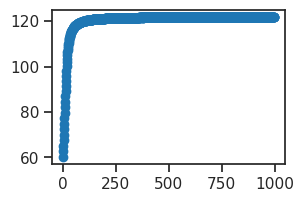

In [19]:
plot(u_norm.mean(0), marker='o');

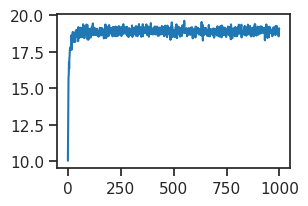

In [20]:
plot(r_norm.mean(0));

In [21]:
# plot(v_norm.mean(0), marker='o');
# plot(a_norm.mean(0), marker='o');

tensor([17.7430, 17.5210, 17.1547, 17.2491, 17.6267], device='cuda:0')

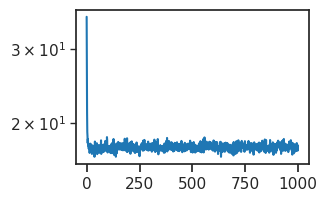

In [21]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

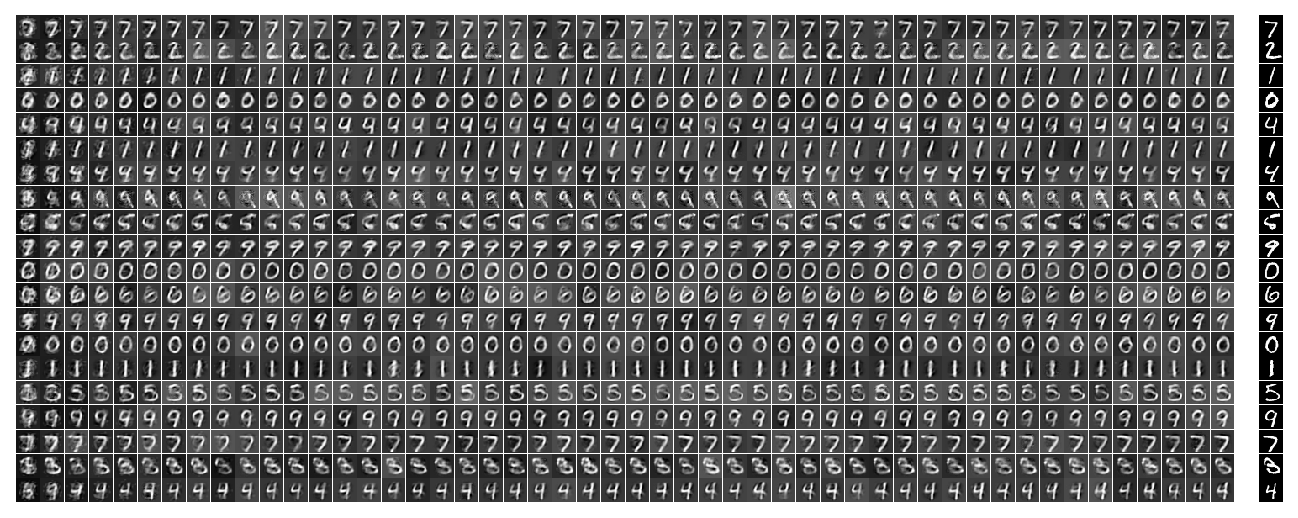

In [22]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

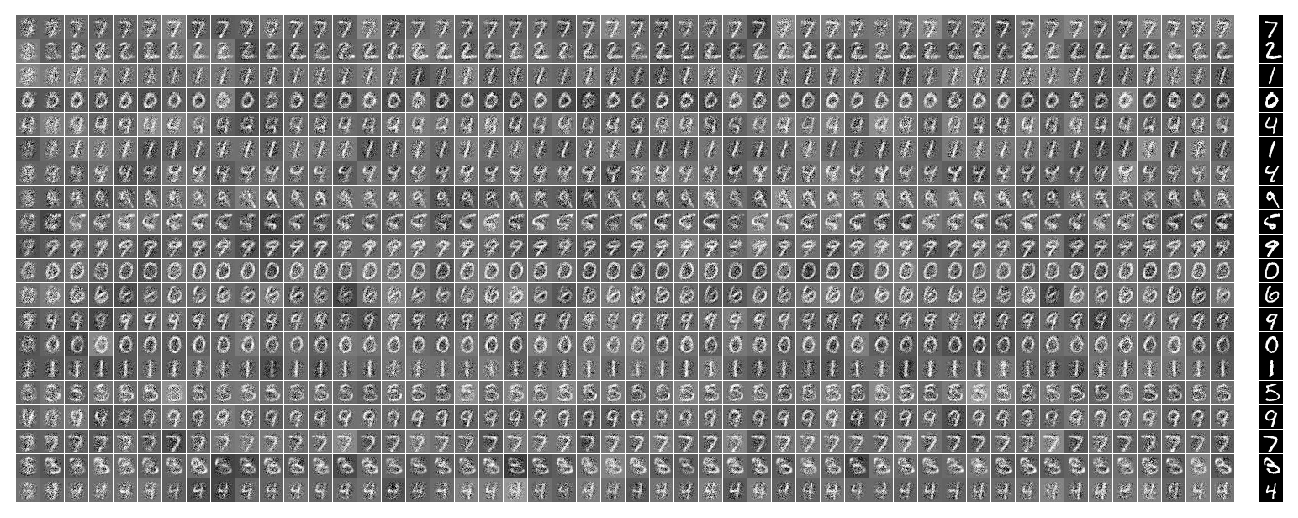

In [23]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

tensor([3.4327, 3.1137, 3.5596, 3.0325, 3.2864], device='cuda:0')

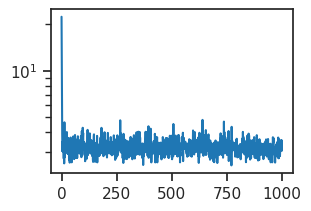

In [24]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([-1458.4009, -1449.2240, -1471.3936, -1456.8826, -1457.9556],
       device='cuda:0')

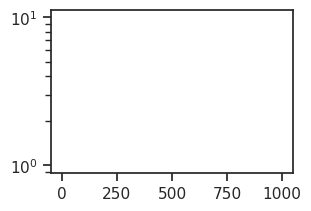

In [25]:
fig, ax = create_figure()

x2p = output['loss_recon'].mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([17.7430, 17.5210, 17.1547, 17.2491, 17.6267], device='cuda:0')

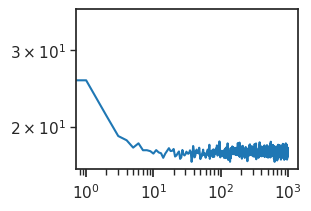

In [26]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(xscale='log', yscale='log');

x2p[-5:]

In [27]:
print(tr.model.layer)

PoissonLayer(input_dim=784,latent_dim=256, beta_inner=1, temp=0.05)